In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

In [8]:
cale_date = "../data/raw/Crop_recommendation.csv"
df = pd.read_csv(cale_date)

X = df.drop('label', axis=1)
y = df['label']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import pandas as pd

modele = {
    "KNN": KNeighborsClassifier(),
    "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost (Ales)": xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', max_depth=5, learning_rate=0.1, random_state=42, n_jobs=1)
}

comparatie_rezultate = []

for nume, mod in modele.items():
    mod.fit(X_train_scaled, y_train)
    sc_train = mod.score(X_train_scaled, y_train)
    sc_test = mod.score(X_test_scaled, y_test)
    comparatie_rezultate.append({
        "Model": nume,
        "Acuratețe Train": f"{sc_train * 100:.2f}%",
        "Acuratețe Test": f"{sc_test * 100:.2f}%"
    })

df_comparatie = pd.DataFrame(comparatie_rezultate)
print("=== REZULTATE COMPARATIVE CONCURS ===")
print(df_comparatie.to_string(index=False))

=== REZULTATE COMPARATIVE CONCURS ===
           Model Acuratețe Train Acuratețe Test
             KNN          98.47%         97.95%
SVM (RBF Kernel)          98.58%         98.41%
   Random Forest         100.00%         99.55%
  XGBoost (Ales)         100.00%         98.86%


In [13]:
model_final = modele["Random Forest"]
rf_acc = model_final.score(X_test_scaled, y_test)
print(rf_acc)

0.9954545454545455


In [ ]:
y_pred = model_final.predict(X_test_scaled)
f1_ponderat = f1_score(y_test, y_pred, average='weighted')
print(f1_ponderat)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

0.9884930494686593
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.85      0.92        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       0.91      1.00      0.95        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      pa

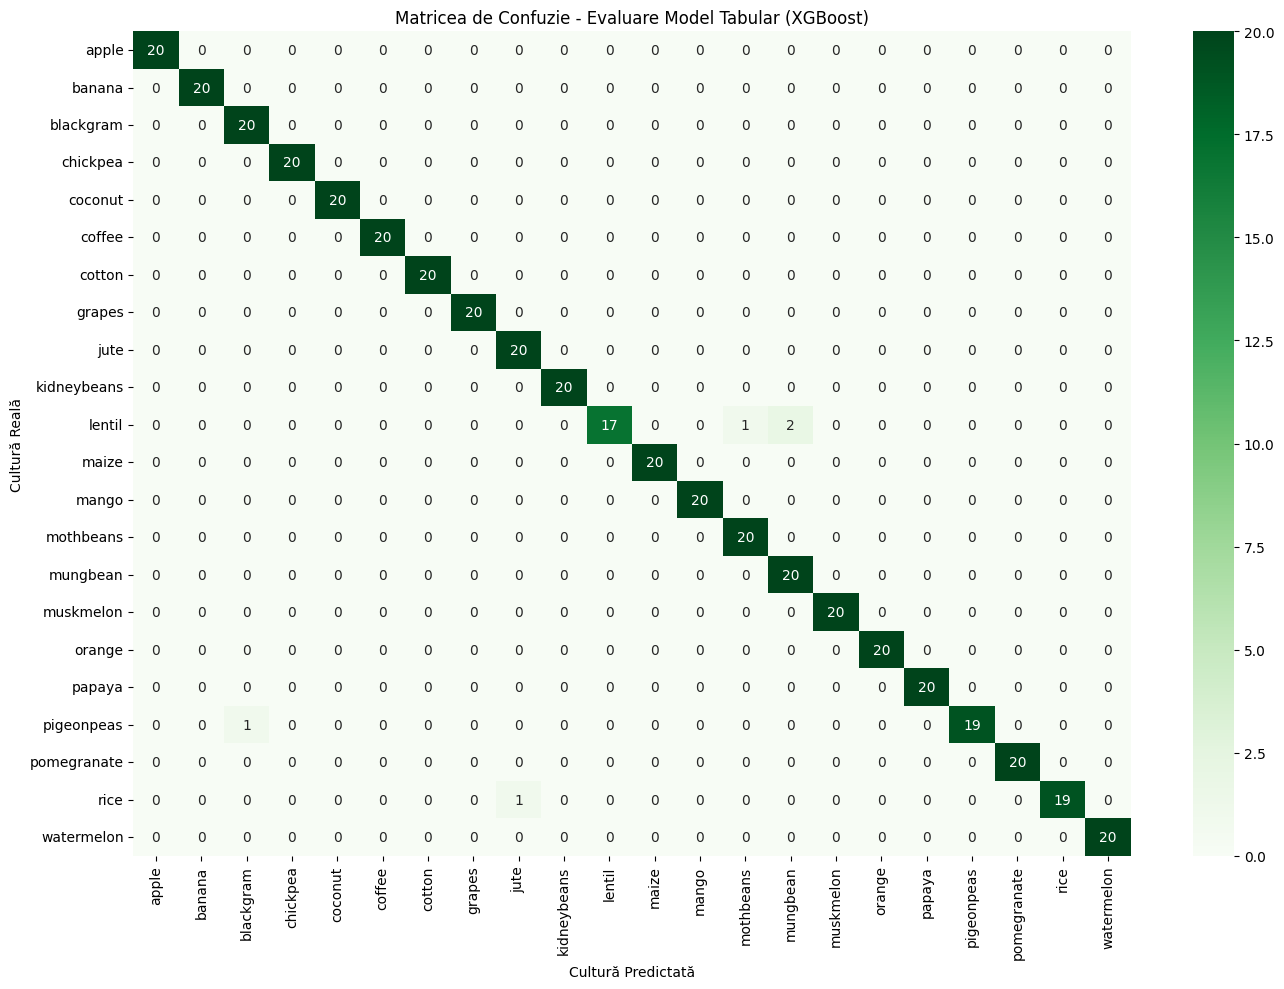

['../models/soil_label_encoder.pkl']

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Matricea de Confuzie - Evaluare Model Tabular (Random Forest)')
plt.ylabel('Cultură Reală')
plt.xlabel('Cultură Predictată')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

os.makedirs('../models', exist_ok=True)
joblib.dump(model_final, '../models/xgboost_soil_model.pkl')
joblib.dump(scaler, '../models/soil_scaler.pkl')
joblib.dump(label_encoder, '../models/soil_label_encoder.pkl')